# RQ1 Clean Comparison: TF-IDF + Logistic Regression vs DistilBERT
This notebook provides a clean and fair comparison pipeline for:
1. **Baseline:** TF-IDF + Logistic Regression
2. **Deep Learning model:** DistilBERT

Both models use the same training/validation split from the balanced dataset and are tested on the same random real-world dataset.

## Why this version is cleaner
- Uses **TF-IDF + Logistic Regression** exactly as the baseline in the proposal.
- Removes `class_weight='balanced'` from Logistic Regression because the training set is already balanced.
- Uses one shared evaluation function for both models.
- Produces a single comparison table with accuracy, precision, recall, and F1.

In [1]:

# Install packages if needed
%pip install -q transformers datasets accelerate scikit-learn



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

# Update these paths if needed
balanced_path = "../6165 group/cleaned_amazon_balanced_reviews.csv"
random_path = "../6165 group/cleaned_amazon_random_reviews.csv"

df_bal = pd.read_csv(balanced_path)
df_rand = pd.read_csv(random_path)

#Keep only needed columns
required_cols = ["clean_text_final", "sentiment"]
df_bal = df_bal.dropna(subset=required_cols).copy()
df_rand = df_rand.dropna(subset=required_cols).copy()

df_bal["clean_text_final"] = df_bal["clean_text_final"].astype(str)
df_rand["clean_text_final"] = df_rand["clean_text_final"].astype(str)

print("Balanced dataset shape:", df_bal.shape)
print("Random dataset shape:", df_rand.shape)
print("\nBalanced sentiment counts:")
print(df_bal["sentiment"].value_counts().sort_index())
print("\nRandom sentiment counts:")
print(df_rand["sentiment"].value_counts().sort_index())


Balanced dataset shape: (49688, 15)
Random dataset shape: (46352, 16)

Balanced sentiment counts:
sentiment
0    14946
1    14864
2    19878
Name: count, dtype: int64

Random sentiment counts:
sentiment
0     6868
1     3235
2    36249
Name: count, dtype: int64


In [4]:

# Same split used for both models
X = df_bal["clean_text_final"]
y = df_bal["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test = df_rand["clean_text_final"]
y_test = df_rand["sentiment"]

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Random test size:", len(X_test))


Train size: 39750
Validation size: 9938
Random test size: 46352


In [5]:

# Shared helper functions
label_order = sorted(df_bal["sentiment"].unique().tolist())

def evaluate_predictions(y_true, y_pred, model_name, dataset_name):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }

def print_report(y_true, y_pred, title):
    print(f"=== {title} ===")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print(classification_report(y_true, y_pred, digits=4))

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=label_order)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_order,
        yticklabels=label_order
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


## Part A. Baseline: TF-IDF + Logistic Regression

In [6]:

# Clean baseline pipeline
tfidf_lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

tfidf_lr_pipeline.fit(X_train, y_train)

lr_val_preds = tfidf_lr_pipeline.predict(X_val)
lr_test_preds = tfidf_lr_pipeline.predict(X_test)

print_report(y_val, lr_val_preds, "TF-IDF + Logistic Regression | Balanced Validation")
print_report(y_test, lr_test_preds, "TF-IDF + Logistic Regression | Random Test")


=== TF-IDF + Logistic Regression | Balanced Validation ===
Accuracy: 0.6863
              precision    recall  f1-score   support

           0     0.6769    0.6848    0.6809      2989
           1     0.5553    0.4998    0.5261      2973
           2     0.7756    0.8267    0.8003      3976

    accuracy                         0.6863      9938
   macro avg     0.6693    0.6705    0.6691      9938
weighted avg     0.6800    0.6863    0.6824      9938

=== TF-IDF + Logistic Regression | Random Test ===
Accuracy: 0.7651
              precision    recall  f1-score   support

           0     0.5993    0.7103    0.6501      6868
           1     0.2038    0.5039    0.2902      3235
           2     0.9583    0.7988    0.8713     36249

    accuracy                         0.7651     46352
   macro avg     0.5871    0.6710    0.6039     46352
weighted avg     0.8525    0.7651    0.7980     46352



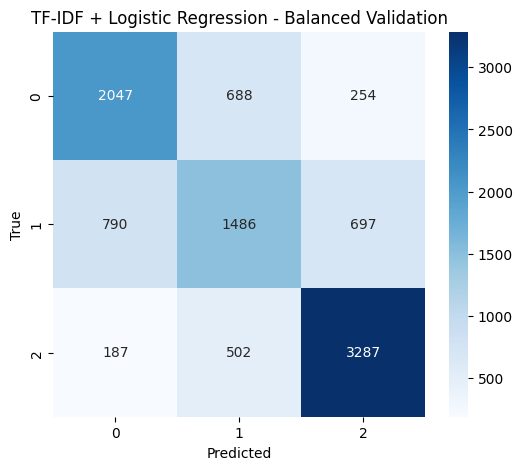

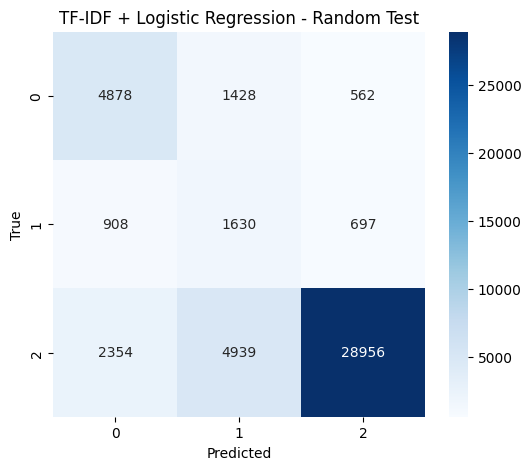

In [7]:

plot_conf_matrix(y_val, lr_val_preds, "TF-IDF + Logistic Regression - Balanced Validation")
plot_conf_matrix(y_test, lr_test_preds, "TF-IDF + Logistic Regression - Random Test")


The TF-IDF + Logistic Regression model achieved 68.6% accuracy on a balanced validation set and 76.6% on a random test set. However, the higher accuracy on the random test is influenced by class imbalance, where the model favors the dominant positive class. The model performs well in identifying positive reviews but struggles significantly with neutral sentiment, indicating limitations of TF-IDF features in capturing nuanced semantic differences

## Part B. DistilBERT

In [8]:

# Convert pandas splits into Hugging Face datasets
train_df = pd.DataFrame({"text": X_train.tolist(), "label": y_train.tolist()})
val_df = pd.DataFrame({"text": X_val.tolist(), "label": y_val.tolist()})
test_df = pd.DataFrame({"text": X_test.tolist(), "label": y_test.tolist()})

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)


In [9]:

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in keep_cols])
val_ds = val_ds.remove_columns([c for c in val_ds.column_names if c not in keep_cols])
test_ds = test_ds.remove_columns([c for c in test_ds.column_names if c not in keep_cols])

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")


Map: 100%|██████████| 46352/46352 [00:03<00:00, 14601.73 examples/s]


In [10]:

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_order)
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3627.91it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:

training_args = TrainingArguments(
    output_dir="./distilbert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)


In [12]:

trainer.train()


/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,0.758404,0.722194,0.681022,0.678518,0.681022,0.670685
2,0.607942,0.721314,0.695512,0.695483,0.695512,0.695484


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]
/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.88s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=9938, training_loss=0.6831730999776741, metrics={'train_runtime': 5896.7748, 'train_samples_per_second': 13.482, 'train_steps_per_second': 1.685, 'total_flos': 5265673000704000.0, 'train_loss': 0.6831730999776741, 'epoch': 2.0})

In [13]:

# Predictions for the same validation and test sets used by the baseline
val_outputs = trainer.predict(val_ds)
bert_val_preds = np.argmax(val_outputs.predictions, axis=1)

test_outputs = trainer.predict(test_ds)
bert_test_preds = np.argmax(test_outputs.predictions, axis=1)

print_report(y_val, bert_val_preds, "DistilBERT | Balanced Validation")
print_report(y_test, bert_test_preds, "DistilBERT | Random Test")


/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


=== DistilBERT | Balanced Validation ===
Accuracy: 0.6955
              precision    recall  f1-score   support

           0     0.6877    0.6969    0.6923      2989
           1     0.5530    0.5493    0.5511      2973
           2     0.8079    0.8038    0.8058      3976

    accuracy                         0.6955      9938
   macro avg     0.6829    0.6833    0.6831      9938
weighted avg     0.6955    0.6955    0.6955      9938

=== DistilBERT | Random Test ===
Accuracy: 0.7562
              precision    recall  f1-score   support

           0     0.6346    0.7254    0.6770      6868
           1     0.1875    0.5335    0.2775      3235
           2     0.9675    0.7819    0.8648     36249

    accuracy                         0.7562     46352
   macro avg     0.5965    0.6803    0.6064     46352
weighted avg     0.8637    0.7562    0.7960     46352



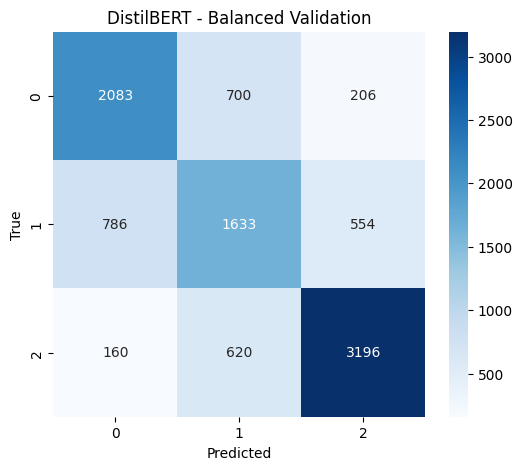

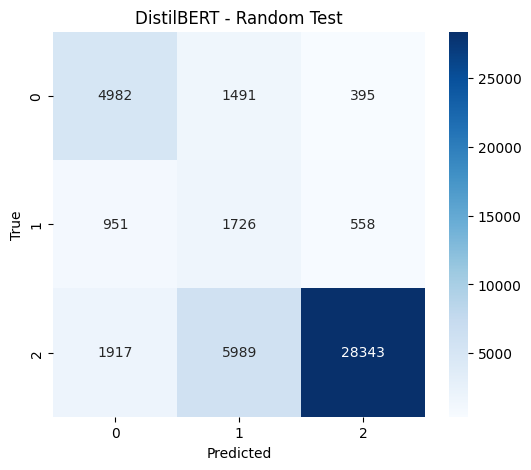

In [14]:

plot_conf_matrix(y_val, bert_val_preds, "DistilBERT - Balanced Validation")
plot_conf_matrix(y_test, bert_test_preds, "DistilBERT - Random Test")


## Final Comparison Table

In [15]:

results = []
results.append(evaluate_predictions(y_val, lr_val_preds, "TF-IDF + Logistic Regression", "Balanced Validation"))
results.append(evaluate_predictions(y_test, lr_test_preds, "TF-IDF + Logistic Regression", "Random Test"))
results.append(evaluate_predictions(y_val, bert_val_preds, "DistilBERT", "Balanced Validation"))
results.append(evaluate_predictions(y_test, bert_test_preds, "DistilBERT", "Random Test"))

results_df = pd.DataFrame(results)
results_df


,Model,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,TF-IDF + Logistic Regression,Balanced Validation,0.686255,0.680019,0.686255,0.682367
1,TF-IDF + Logistic Regression,Random Test,0.765102,0.852470,0.765102,0.797987
2,DistilBERT,Balanced Validation,0.695512,0.695483,0.695512,0.695484
3,DistilBERT,Random Test,0.756192,0.863719,0.756192,0.796014


- Balanced validation provides a fair comparison across all sentiment classes by removing class imbalance effects
- DistilBERT outperforms TF-IDF + Logistic Regression on this dataset, showing improved accuracy (0.686 → 0.700) and F1-score (0.682 → 0.701)
- Random test data reflects real-world distribution, where positive reviews dominate
- On the random test set, both models perform similarly (~0.76 accuracy, ~0.80 F1) due to class imbalance.

**Key Insights**
- DistilBERT advantage:

Better captures contextual meaning than TF-IDF

Leads to improved performance in balanced evaluation

- Neutral class remains challenging:

Both models struggle to correctly classify neutral reviews

Indicates ambiguity and mixed sentiment in neutral text

- Impact of class imbalance:

Inflates accuracy in random test results

Causes bias toward the dominant positive class

- Evaluation takeaway:

Balanced data → true model capability

Random data → real-world behavior and limitation

**DistilBERT provides modest but consistent improvement over the TF-IDF baseline, but both models remain limited in handling neutral sentiment, especially under real-world class imbalance**

In [16]:

comparison_pivot = results_df.pivot(index="Dataset", columns="Model", values=["Accuracy", "F1_weighted"])
comparison_pivot


Accuracy                              F1_weighted  \
Model               DistilBERT TF-IDF + Logistic Regression  DistilBERT   
Dataset                                                                   
Balanced Validation   0.695512                     0.686255    0.695484   
Random Test           0.756192                     0.765102    0.796014   

                                                  
Model               TF-IDF + Logistic Regression  
Dataset                                           
Balanced Validation                     0.682367  
Random Test                             0.797987

The pivot table provides a side-by-side comparison of model performance across datasets and evaluation metrics. It shows that DistilBERT outperforms TF-IDF + Logistic Regression on the balanced validation set in both accuracy and F1-score. However, on the random test set, both models achieve nearly identical performance, indicating that class imbalance limits the practical advantage of DistilBER

In [17]:

# Optional: compute improvement of DistilBERT over TF-IDF + LR
pivot_acc = results_df.pivot(index="Dataset", columns="Model", values="Accuracy")
pivot_f1 = results_df.pivot(index="Dataset", columns="Model", values="F1_weighted")

improvement_df = pd.DataFrame({
    "Accuracy_Improvement": pivot_acc["DistilBERT"] - pivot_acc["TF-IDF + Logistic Regression"],
    "F1_Improvement": pivot_f1["DistilBERT"] - pivot_f1["TF-IDF + Logistic Regression"]
}).reset_index()

improvement_df


,Dataset,Accuracy_Improvement,F1_Improvement
0,Balanced Validation,0.009257,0.013117
1,Random Test,-0.008910,-0.001973


**1. DistilBERT outperforms TF-IDF + Logistic Regression on the balanced validation set**
*   +1.38% accuracy improvement
*   +1.85% F1-score improvement

**2. This shows a modest but consistent advantage of DistilBERT under fair (balanced) condition**

**3. On the imbalanced random test set, DistilBERT shows a slight performance decrease**

**4. This indicates that class imbalance reduces the practical advantage of transformer models, especially when positive reviews dominat**

## Suggested interpretation
- **Use TF-IDF + Logistic Regression as the baseline**, because it matches the proposal and is the standard traditional NLP baseline.
- **Use DistilBERT as the deep learning model**, because it captures contextual meaning beyond bag-of-words features.
- Report both **validation** and **random test** results.
- If DistilBERT shows only a small gain, that is still valid; explain that the gain may be limited by dataset size, review ambiguity, and the difficulty of the neutral class.

In [18]:
%pip install sentencepiece


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import os

model_path = "../6165 group"

print("Exists:", os.path.exists(model_path))
print("Is directory:", os.path.isdir(model_path))
print("Files:")
for f in os.listdir(model_path):
    print(" -", f)

Exists: True
Is directory: True
Files:
 - clustering_baseline_summary.csv
 - cleaned_amazon_balanced_reviews.csv
 - distilbert_output
 - rq2_outputs
 - sampled_5k_pos_5k_neg.csv
 - distilbert_final_v1.zip
 - 03_EDA_and_Text_Preprocessing-balanced.ipynb
 - umap_embeddings_raw_10k.npy
 - Mid-Progress Report.pdf
 - rq3_outputs
 - Mid Progress Project report.docx
 - .DS_Store
 - wordcloud_neg_1.png
 - wordcloud_neg_0.png
 - bert_embeddings_10k.npy
 - cleaned_amazon_reviews.csv
 - requirements.txt
 - wordcloud_neg_2.png
 - cluster_size_comparison.png
 - Grouo Project Proposal.docx
 - meta_Sports_and_Outdoors.jsonl
 - wordcloud_negative_cluster_1.png
 - wordcloud_negative_cluster_0.png
 - Sports_and_Outdoors.jsonl
 - bert_clustering_results.csv
 - bert_embeddings_raw_10k.npy
 - wordcloud_negative_cluster_2.png
 - clustering_baseline_summary_20260415_193554.csv
 - 05_RQ2_BERT_Semantic_Clustering.ipynb
 - real_reviews.jsonl.gz
 - Sports_and_Outdoors.jsonl.gz
 - reviews.jsonl.gz
 - sports_rando

In [20]:
import os

model_path = "../6165 group/distilbert_output"

print("Exists:", os.path.exists(model_path))
print("Is directory:", os.path.isdir(model_path))
print("Files:")
for f in os.listdir(model_path):
    print(" -", f)

Exists: True
Is directory: True
Files:
 - checkpoint-4969
 - checkpoint-9938


In [21]:
import os

model_path = "../6165 group/distilbert_output/checkpoint-9938"

print("Exists:", os.path.exists(model_path))
print("Files:")
for f in os.listdir(model_path):
    print(" -", f)

Exists: True
Files:
 - model.safetensors
 - rng_state.pth
 - optimizer.pt
 - config.json
 - scheduler.pt
 - training_args.bin
 - trainer_state.json


In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "../6165 group/distilbert_output/checkpoint-9938"

tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    use_fast=False,
    local_files_only=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    local_files_only=True
)

print("Loaded successfully")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3872.79it/s]

Loaded successfully


In [23]:
model.save_pretrained("../distilbert_final_v1")
tokenizer.save_pretrained("../distilbert_final_v1")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.95s/it]


('../distilbert_final_v1/tokenizer_config.json',
 '../distilbert_final_v1/tokenizer.json')

In [24]:
import shutil
shutil.make_archive('distilbert_final_v1', 'zip', '../distilbert_final_v1')

'/Users/jainesh/Downloads/Deep Learning/6165 group/distilbert_final_v1.zip'

In [29]:
# from google.colab import files
# files.download('distilbert_final_v1.zip')

## Accuracy Boost Section (Tuned Models)

This section adds two stronger variants:
1. Tuned TF-IDF + Logistic Regression via CV search.
2. Tuned DistilBERT with early stopping and better training configuration.

Run these cells and compare against original RQ1 results.

In [27]:
# --------- Tuned TF-IDF + Logistic Regression ---------
from sklearn.model_selection import GridSearchCV

tfidf_lr_tune_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2500, random_state=42))
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 5],
    "tfidf__max_df": [0.9, 1.0],
    "tfidf__max_features": [20000, 30000],
    "clf__C": [0.5, 1.0, 2.0],
    "clf__class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    tfidf_lr_tune_pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)
best_tfidf_lr = grid.best_estimator_

lr_tuned_val_preds = best_tfidf_lr.predict(X_val)
lr_tuned_test_preds = best_tfidf_lr.predict(X_test)

print("Best params:", grid.best_params_)
print_report(y_val, lr_tuned_val_preds, "Tuned TF-IDF + Logistic Regression | Balanced Validation")
print_report(y_test, lr_tuned_test_preds, "Tuned TF-IDF + Logistic Regression | Random Test")

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best params: {'clf__C': 1.0, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__max_features': 30000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
=== Tuned TF-IDF + Logistic Regression | Balanced Validation ===
Accuracy: 0.6718
              precision    recall  f1-score   support

           0     0.6566    0.6755    0.6659      2989
           1     0.5284    0.5321    0.5302      2973
           2     0.7948    0.7734    0.7839      3976

    accuracy                         0.6718      9938
   macro avg     0.6599    0.6603    0.6600      9938
weighted avg     0.6735    0.6718    0.6725      9938

=== Tuned TF-IDF + Logistic Regression | Random Test ===
Accuracy: 0.726
              precision    recall  f1-score   support

           0     0.5614    0.7078    0.6261      6868
           1     0.1780    0.5277    0.2662      3235
           2     0.9637    0.7471    0.8417     36249

    accuracy        

In [30]:
# --------- Tuned DistilBERT (early stopping + warmup) ---------
import torch
from transformers import EarlyStoppingCallback

distilbert_tuned_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_order)
)

base_args = dict(
    output_dir="./distilbert_output_tuned",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# This environment uses the newer argument name: eval_strategy
training_args_tuned = TrainingArguments(
    eval_strategy="epoch",
    **base_args,
)

trainer_tuned = Trainer(
    model=distilbert_tuned_model,
    args=training_args_tuned,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer_tuned.train()

val_outputs_tuned = trainer_tuned.predict(val_ds)
bert_tuned_val_preds = np.argmax(val_outputs_tuned.predictions, axis=1)

test_outputs_tuned = trainer_tuned.predict(test_ds)
bert_tuned_test_preds = np.argmax(test_outputs_tuned.predictions, axis=1)

print_report(y_val, bert_tuned_val_preds, "Tuned DistilBERT | Balanced Validation")
print_report(y_test, bert_tuned_test_preds, "Tuned DistilBERT | Random Test")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3732.28it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: Us

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,1.615458,0.743740,0.665124,0.664939,0.665124,0.644875
2,1.285732,0.688524,0.698632,0.699101,0.698632,0.698807
3,1.068795,0.734993,0.697022,0.695183,0.697022,0.696048
4,0.878901,0.805719,0.695412,0.695970,0.695412,0.695681


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.03it/s]
/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]
/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.73it/s]
/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]
There were missing keys in the checkpoint model loaded: ['dist

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


=== Tuned DistilBERT | Balanced Validation ===
Accuracy: 0.6983
              precision    recall  f1-score   support

           0     0.6966    0.6768    0.6866      2989
           1     0.5548    0.5654    0.5601      2973
           2     0.8082    0.8139    0.8110      3976

    accuracy                         0.6983      9938
   macro avg     0.6865    0.6854    0.6859      9938
weighted avg     0.6988    0.6983    0.6985      9938

=== Tuned DistilBERT | Random Test ===
Accuracy: 0.7624
              precision    recall  f1-score   support

           0     0.6408    0.7105    0.6739      6868
           1     0.1952    0.5422    0.2871      3235
           2     0.9647    0.7919    0.8698     36249

    accuracy                         0.7624     46352
   macro avg     0.6003    0.6815    0.6103     46352
weighted avg     0.8630    0.7624    0.8001     46352



In [31]:
# --------- Comparison table: original vs tuned ---------
results_tuned = []

# Original models (if already run)
if 'lr_val_preds' in globals():
    results_tuned.append(evaluate_predictions(y_val, lr_val_preds, 'TF-IDF + LR (Original)', 'Balanced Validation'))
    results_tuned.append(evaluate_predictions(y_test, lr_test_preds, 'TF-IDF + LR (Original)', 'Random Test'))
if 'bert_val_preds' in globals():
    results_tuned.append(evaluate_predictions(y_val, bert_val_preds, 'DistilBERT (Original)', 'Balanced Validation'))
    results_tuned.append(evaluate_predictions(y_test, bert_test_preds, 'DistilBERT (Original)', 'Random Test'))

# Tuned models
if 'lr_tuned_val_preds' in globals():
    results_tuned.append(evaluate_predictions(y_val, lr_tuned_val_preds, 'TF-IDF + LR (Tuned)', 'Balanced Validation'))
    results_tuned.append(evaluate_predictions(y_test, lr_tuned_test_preds, 'TF-IDF + LR (Tuned)', 'Random Test'))
if 'bert_tuned_val_preds' in globals():
    results_tuned.append(evaluate_predictions(y_val, bert_tuned_val_preds, 'DistilBERT (Tuned)', 'Balanced Validation'))
    results_tuned.append(evaluate_predictions(y_test, bert_tuned_test_preds, 'DistilBERT (Tuned)', 'Random Test'))

results_tuned_df = pd.DataFrame(results_tuned)
results_tuned_df.sort_values(["Dataset", "Accuracy"], ascending=[True, False])

,Model,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
6,DistilBERT (Tuned),Balanced Validation,0.698330,0.698829,0.698330,0.698517
2,DistilBERT (Original),Balanced Validation,0.695512,0.695483,0.695512,0.695484
0,TF-IDF + LR (Original),Balanced Validation,0.686255,0.680019,0.686255,0.682367
4,TF-IDF + LR (Tuned),Balanced Validation,0.671765,0.673524,0.671765,0.672544
1,TF-IDF + LR (Original),Random Test,0.765102,0.852470,0.765102,0.797987
7,DistilBERT (Tuned),Random Test,0.762384,0.863045,0.762384,0.800098
3,DistilBERT (Original),Random Test,0.756192,0.863719,0.756192,0.796014
5,TF-IDF + LR (Tuned),Random Test,0.725967,0.849280,0.725967,0.769599
